## Step 1: Import Necessary Libraries

In [89]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%pip install scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import statsmodels.formula.api as smf


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Step 2: Import the Dataset

In [7]:
cars_data = pd.read_csv("cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## Step 3: Data Understanding

In [8]:
## 3.1 Perform initial investigation on the data

cars_data.shape

(81, 5)

In [10]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [11]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [13]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Now, Let's check for Assumptions

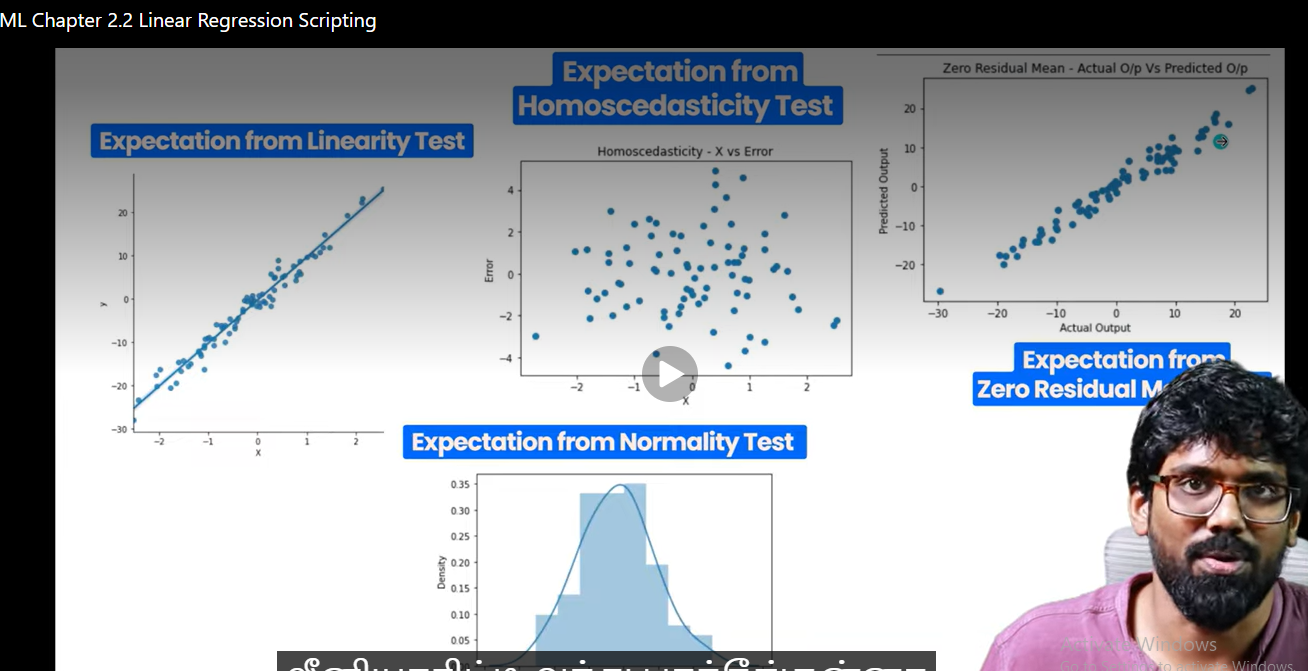

### Test 1: Check for linearity

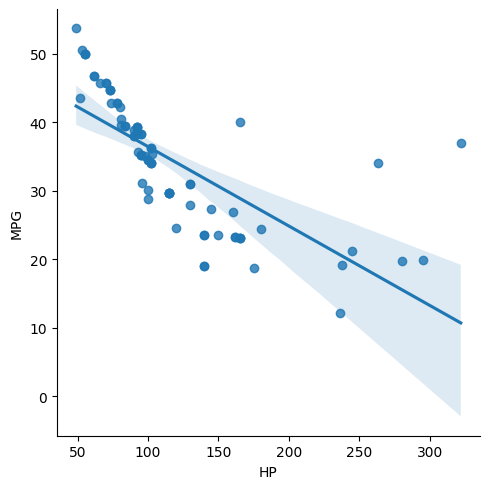

In [19]:
sns.lmplot(data = cars_data, x="HP", y="MPG")

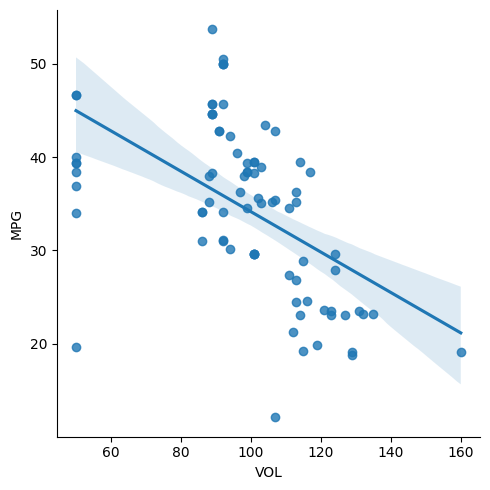

In [20]:
sns.lmplot(data = cars_data, x="VOL", y="MPG")

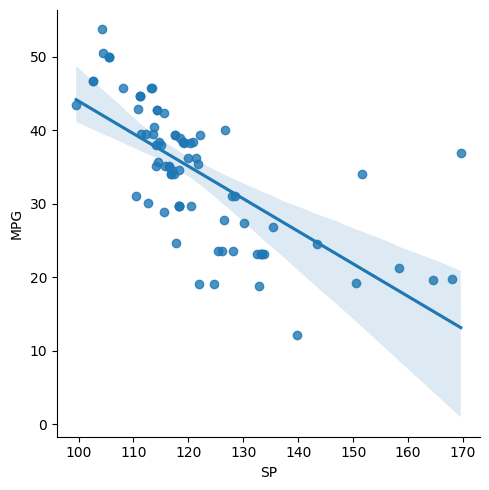

In [21]:
sns.lmplot(data = cars_data, x="SP", y="MPG")

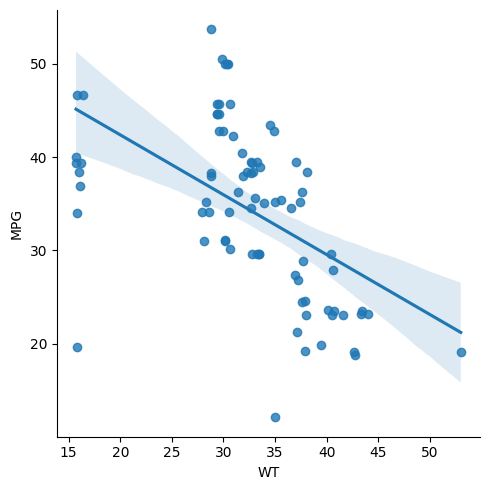

In [22]:
sns.lmplot(data = cars_data, x="WT", y="MPG")

#### Test 1 Linearity test failed - All the input variables are scattered wrt MPG

### Test 2: Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

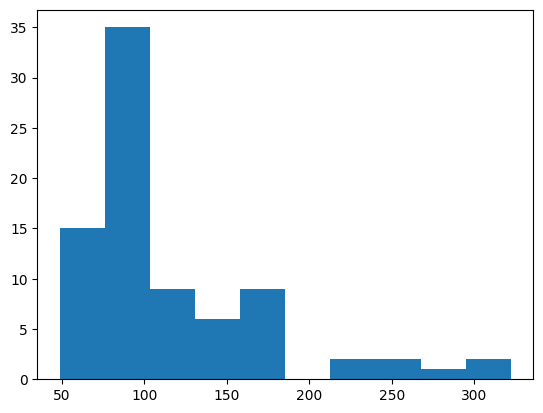

In [24]:
plt.hist(cars_data["HP"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.712859 , 19.4413483, 23.1698376, 26.8983269, 30.6268162,
        34.3553055, 38.0837948, 41.8122841, 45.5407734, 49.2692627,
        52.997752 ]),
 <BarContainer object of 10 artists>)

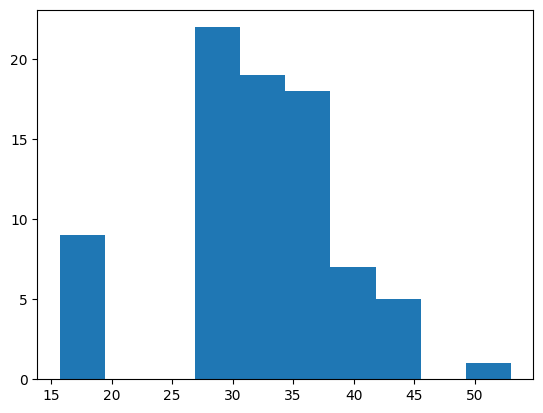

In [27]:
plt.hist(cars_data["WT"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

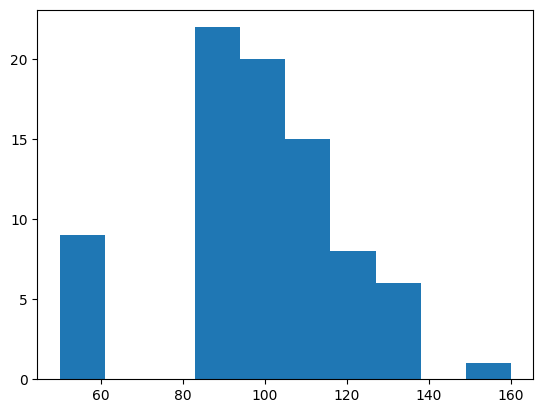

In [28]:
plt.hist(cars_data["VOL"])

### Test 2 Normality Test also failed as the curve does not follow normal distribution

### Test 3: Multicolinearity Test

In [32]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

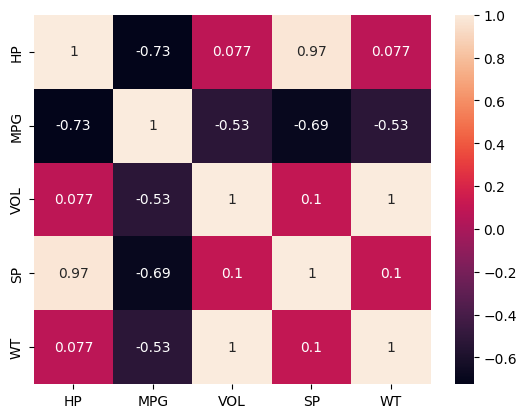

In [35]:
sns.heatmap(corr_matrix, annot = True)

### Test 3 - There is multicolinearity - There input variables must be independent of each other, there should not be any correlation between them.

### Test 4: AutoRegression Passed

### Test Homoscedaccity and zero residual mean test will be done after model training and tested

## 4. Data Preparation

In [52]:
## Split training and testing data

X = cars_data[["HP","VOL","WT","SP"]]
X

,HP,VOL,WT,SP
0,49,89,28.762059,104.185353
1,55,92,30.466833,105.461264
2,55,92,30.193597,105.461264
3,70,92,30.632114,113.461264
4,53,92,29.889149,104.461264
...,...,...,...,...
76,322,50,16.132947,169.598513
77,238,115,37.923113,150.576579
78,263,50,15.769625,151.598513
79,295,119,39.423099,167.944460


In [54]:
y = cars_data[["MPG"]]
y

,MPG
0,53.700681
1,50.013401
2,50.013401
3,45.696322
4,50.504232
...,...
76,36.900000
77,19.197888
78,34.000000
79,19.833733


In [39]:
## There is nothing to prepare because all features are numbers. Features engineering can be applied 

## 5. Model Building

In [51]:
linear_model = LinearRegression()

## 6. Model Training

In [55]:
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
linear_model.intercept_

array([30.67733449])

In [57]:
linear_model.coef_

array([[-0.20544371, -0.33605061,  0.4005734 ,  0.39562693]])

## 7. Model Testing

In [60]:
y_predict = linear_model.predict(X)
y_predict

array([[43.44193491],
       [42.38879267],
       [42.27934159],
       [42.53835954],
       [42.17264833],
       [43.02061861],
       [42.32536067],
       [48.07621831],
       [48.28120214],
       [40.79122782],
       [41.52153184],
       [47.80956756],
       [39.95980209],
       [41.5275785 ],
       [41.76632305],
       [41.61814454],
       [41.15094053],
       [47.98605499],
       [41.30861022],
       [37.87127913],
       [38.57706416],
       [37.35199687],
       [37.8977033 ],
       [39.56251404],
       [39.93380685],
       [46.73870887],
       [35.48165919],
       [38.78152443],
       [38.24861149],
       [36.00285259],
       [34.84604009],
       [37.21630221],
       [37.13919831],
       [34.82541389],
       [37.22361417],
       [37.53950083],
       [39.2714485 ],
       [38.24219872],
       [38.5428639 ],
       [35.93917235],
       [34.21297521],
       [35.36313253],
       [37.50473358],
       [38.07998522],
       [35.79651695],
       [36

## 8. Model Evalutaion

In [81]:
error = y- y_predict
error

cars_data["y_predict"] = y_predict
cars_data["Error"] = error
cars_data

,HP,MPG,VOL,SP,WT,Error,y_predict
0,49,53.700681,89,104.185353,28.762059,10.258746,43.441935
1,55,50.013401,92,105.461264,30.466833,7.624608,42.388793
2,55,50.013401,92,105.461264,30.193597,7.734059,42.279342
3,70,45.696322,92,113.461264,30.632114,3.157962,42.538360
4,53,50.504232,92,104.461264,29.889149,8.331584,42.172648
...,...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904,21.282096
77,238,19.197888,115,150.576579,37.923113,1.298838,17.899050
78,263,34.000000,50,151.598513,15.769625,7.863547,26.136453
79,295,19.833733,119,167.944460,39.423099,7.517121,12.316612


In [97]:
mean_absolute_error(y,y_predict) ##Same units

3.267968236592985

In [98]:
mean_squared_error(y,y_predict) #squrared output units

18.897140673683793

In [99]:
root_mean_squared_error(y,y_predict) ##Normalising the units

4.347084157649101

In [100]:
r2_score(y,y_predict)

0.7705372729796699

In [90]:
linear_stats_model =smf.ols(formula ="MPG~HP+WT+VOL+SP",data =cars_data).fit()

In [96]:
print("R2 Score:", linear_stats_model.rsquared.round(2), "\nAdjusted R2 Score", linear_stats_model.rsquared_adj.round(2))

R2 Score: 0.77 
Adjusted R2 Score 0.76


### Lets Now perform test 5: homoscedasticity test

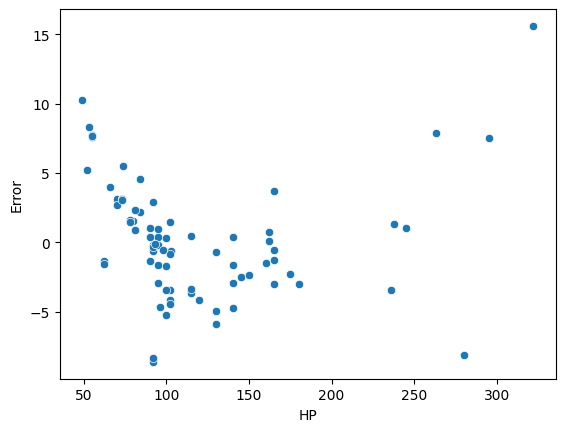

In [70]:
sns.scatterplot( data=cars_data,x="HP",y= "Error")
plt.show()sns.scatterplot( data=cars_data,x="HP",y= "Error")
plt.show()

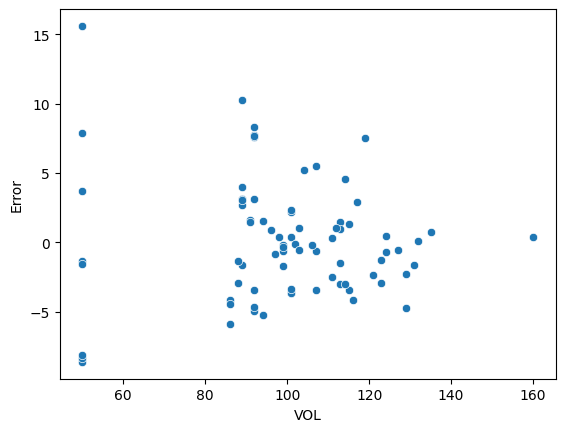

In [71]:
sns.scatterplot( data=cars_data,x="VOL",y= "Error")
plt.show()

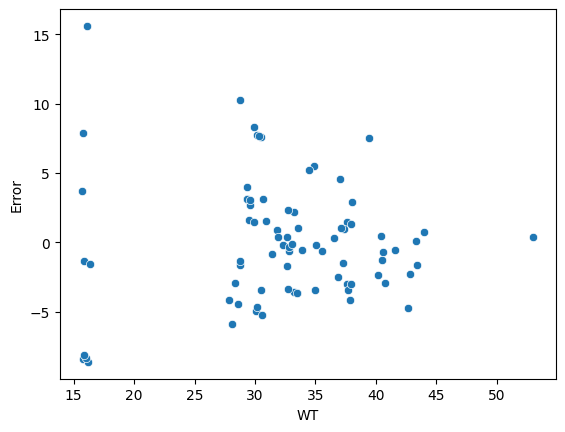

In [72]:
sns.scatterplot( data=cars_data,x="WT",y= "Error")
plt.show()

### Homoscedasticity test also failed as there is no  equal variences across each features

## Test 6: Zero Residuaal Mean test

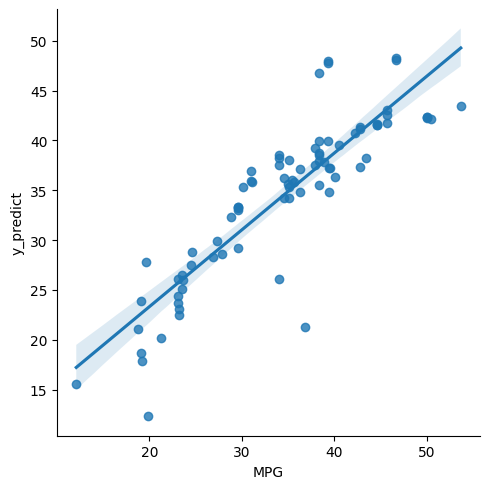

In [76]:
sns.lmplot(cars_data,x="MPG",y="y_predict")

### Test 6 Zero Residual mean test also failed

## 9. Model Deployment

In [78]:
from pickle import dump

In [80]:
dump(obj= linear_model, file= open("linear_intel_file.pkl", mode='wb'))